**Task 1: Document Scanner with Morphological Cleanup**

In [ ]:
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

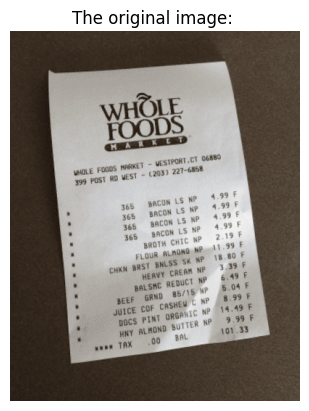

In [ ]:
img = cv2.imread('/content/receipt.jpg')
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("The original image: ")
plt.axis('off')
plt.show()



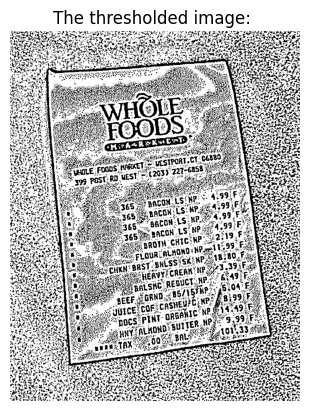

In [ ]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
thresh=cv2.adaptiveThreshold(gray_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
plt.imshow(thresh, cmap='gray')
plt.title("The thresholded image: ")
plt.axis('off')
plt.show()

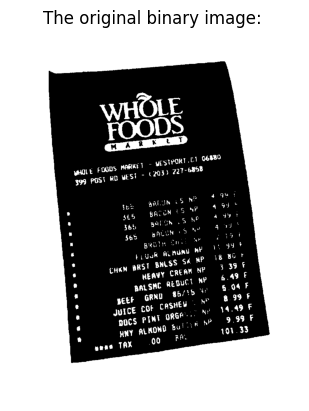

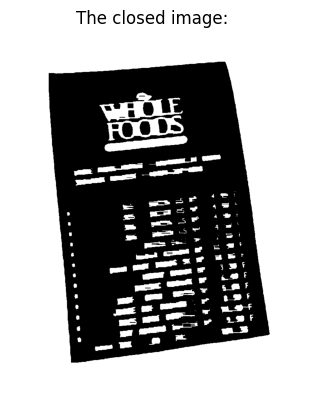

In [ ]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, binary_img = cv2.threshold(gray_img, 128, 255, cv2.THRESH_BINARY_INV)

kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 1))
closed_img = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel_horizontal)

plt.imshow(binary_img, cmap='gray')
plt.title("The original binary image: ")
plt.axis('off')
plt.show()

plt.imshow(closed_img, cmap='gray')
plt.title("The closed image: ")
plt.axis('off')
plt.show()


**Task 2. License Plate Character Isolation**

In [ ]:
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

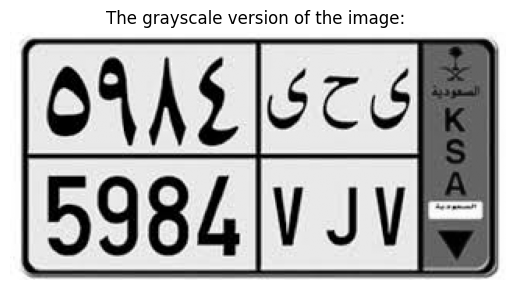

In [ ]:
img_2 = cv2.imread('/content/licensePlateKSA.jpg')
gray_img_2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img_2, cmap='gray')
plt.title("The grayscale version of the image: ")
plt.axis('off')
plt.show()



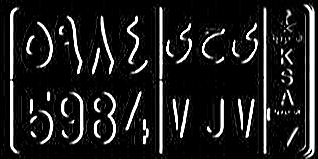

In [ ]:
sobelx = cv2.Sobel(gray_img_2, cv2.CV_64F, 1, 0, ksize=3)
cv2_imshow(sobelx)


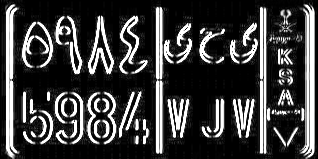

In [ ]:
abs_sobelx = cv2.convertScaleAbs(sobelx)
cv2_imshow(abs_sobelx)


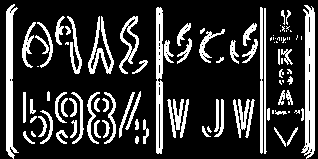

In [ ]:
ret, binary_image = cv2.threshold(abs_sobelx, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2_imshow(binary_image)


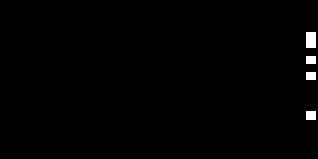

In [ ]:
k = np.ones((3, 10), np.uint8)
opening = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, k)
cv2_imshow(opening)

In [ ]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opening, connectivity=8)

filtered_components = []

for i in range(1, num_labels):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    aspect_ratio = h / w
    if (100 < area < 5000) and (1.5 < aspect_ratio < 5.0):
        filtered_components.append((x, y, w, h))

print(filtered_components)

[(np.int32(306), np.int32(32), np.int32(10), np.int32(16))]


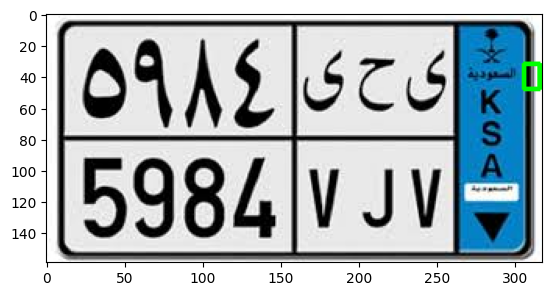

In [ ]:
result_image = img_2.copy()

for (x, y, w, h) in filtered_components:
    cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.show()

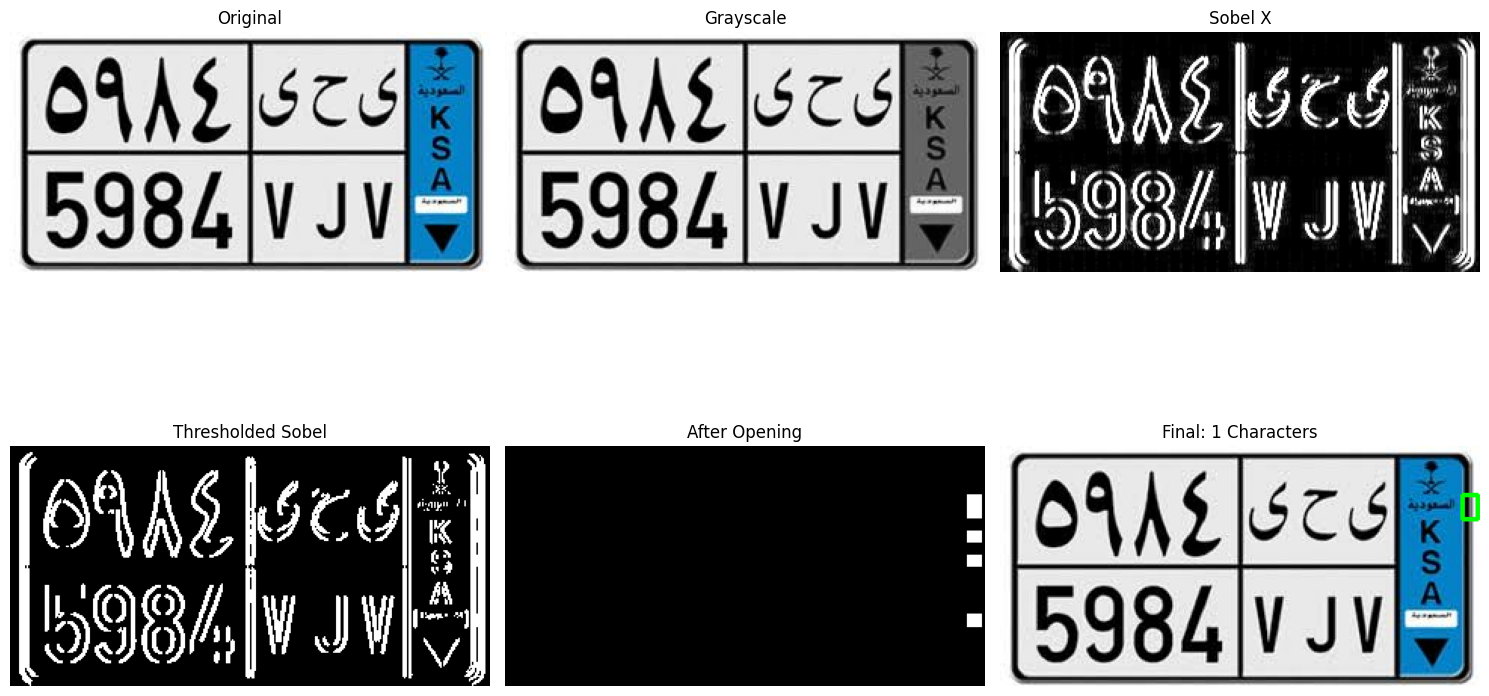

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gray_img_2, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(abs_sobelx, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(binary_image, cmap='gray')
plt.title('Thresholded Sobel')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(opening, cmap='gray')
plt.title('After Opening')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title(f'Final: {len(filtered_components)} Characters')
plt.axis('off')

plt.tight_layout()
plt.show()


**Task 3: Object Segmentation and Counting**

In [ ]:
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

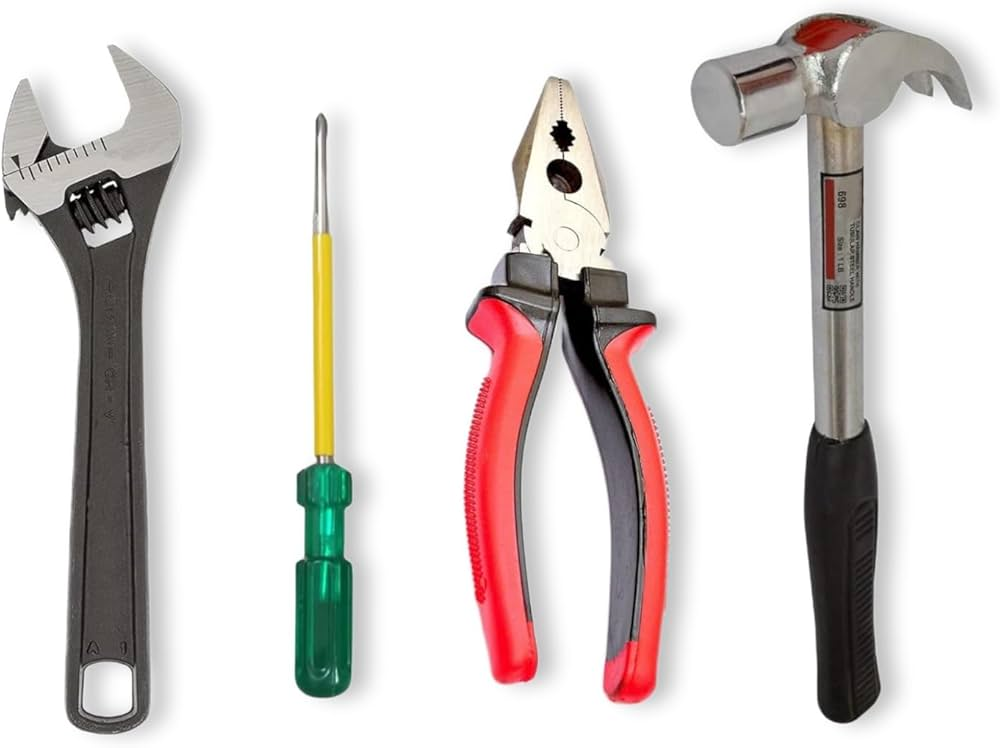

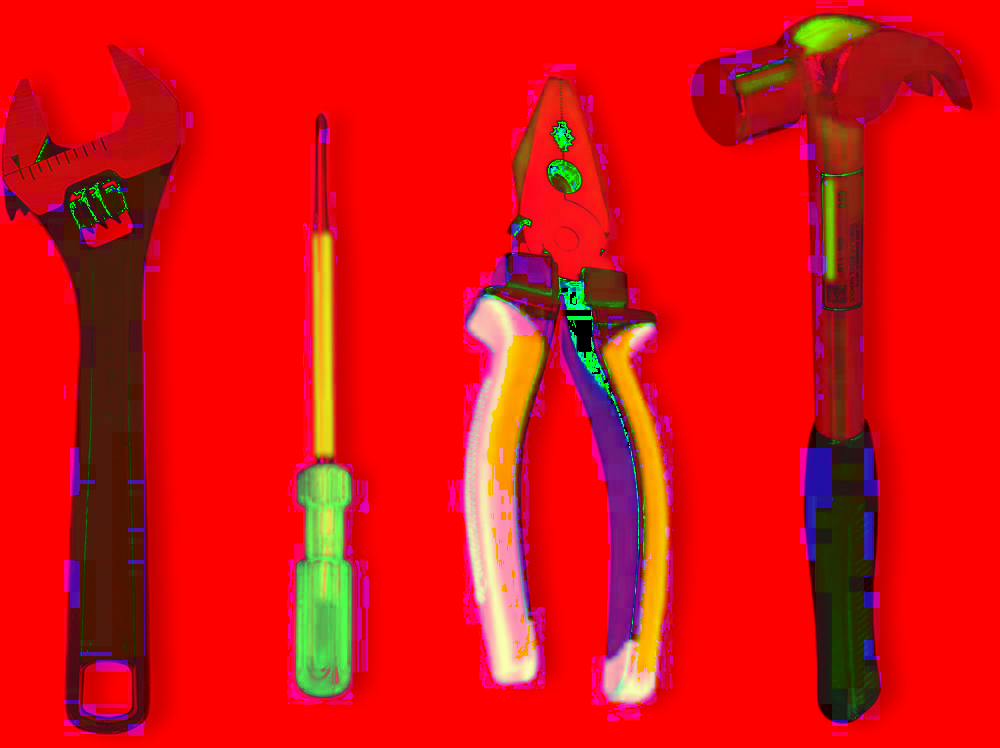

In [ ]:
img_3 = cv2.imread('/content/tools.jpg')
cv2_imshow(img_3)
hsv_img_3 = cv2.cvtColor(img_3, cv2.COLOR_BGR2HSV)
cv2_imshow(hsv_img_3)

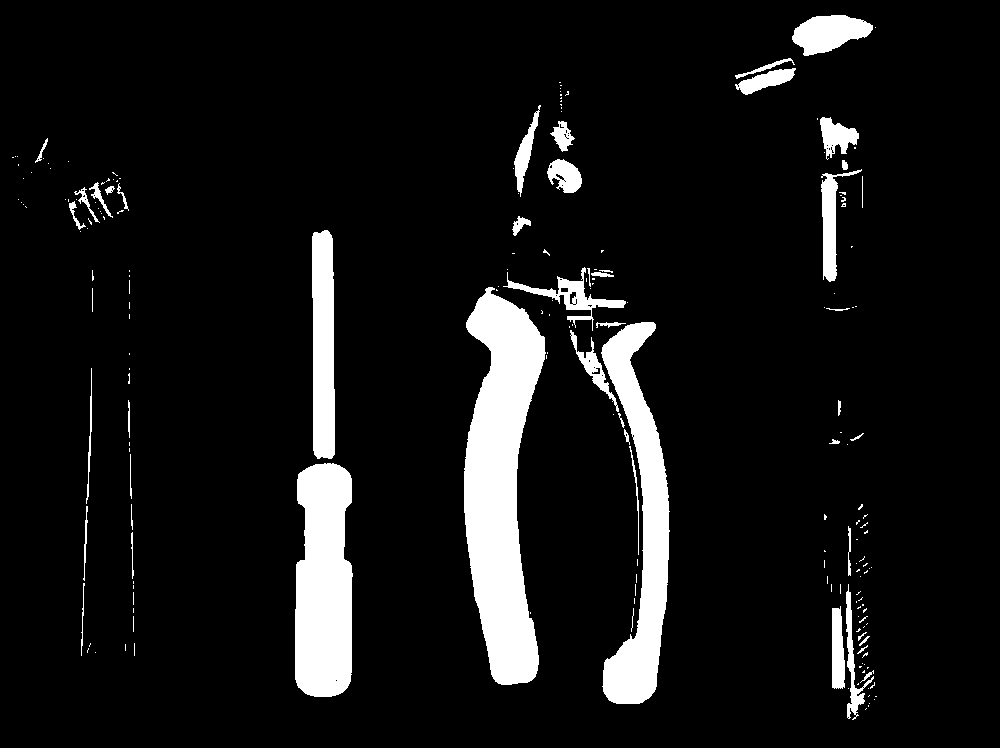

In [ ]:
saturation = hsv_img_3[:, :, 1]
_,b_mask = cv2.threshold(saturation, 50, 255, cv2.THRESH_BINARY)
cv2_imshow(b_mask)

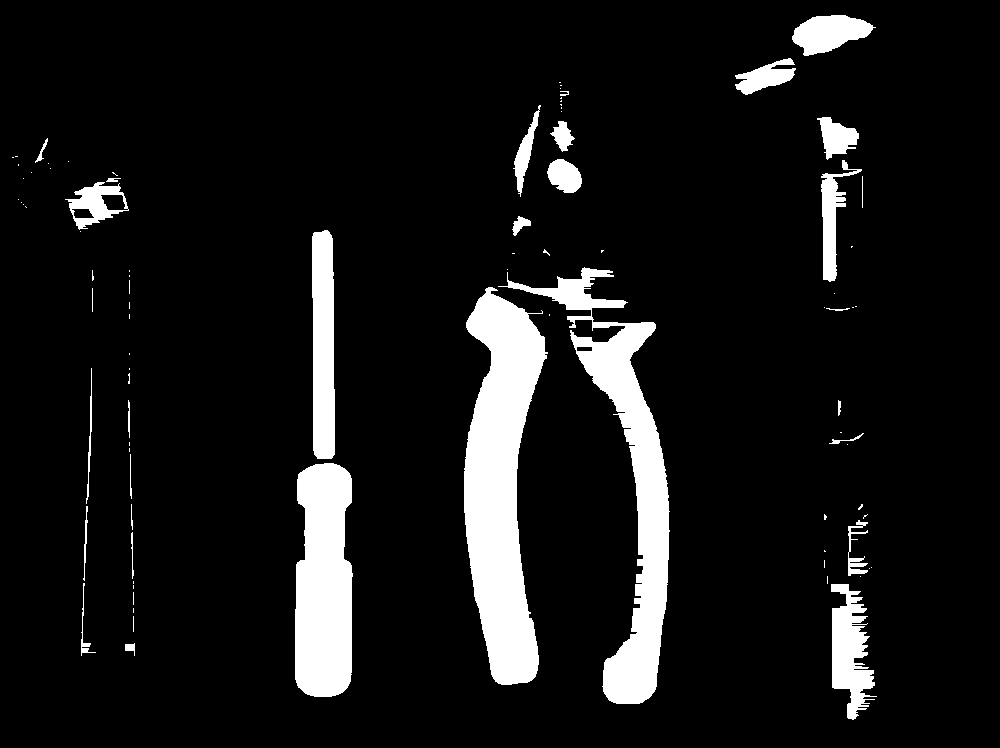

In [ ]:
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 1))
closed_img = cv2.morphologyEx(b_mask, cv2.MORPH_CLOSE, kernel_horizontal)
cv2_imshow(closed_img)

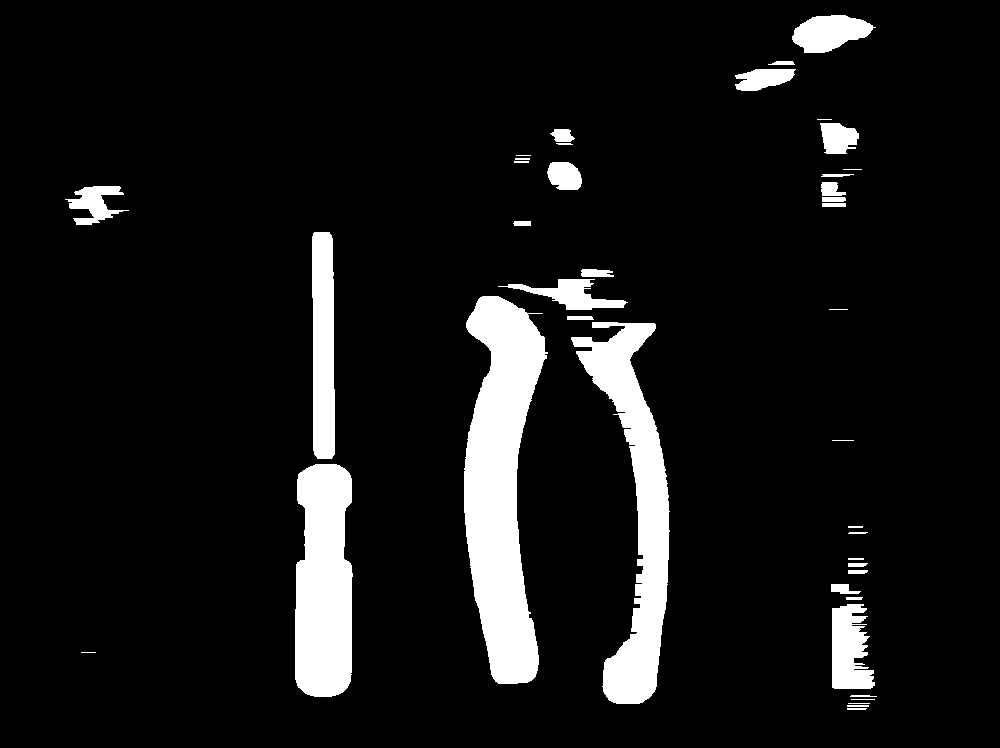

In [ ]:
opening = cv2.morphologyEx(closed_img, cv2.MORPH_OPEN, kernel_horizontal)
cv2_imshow(opening)

In [ ]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opening, connectivity=8)

count = 0
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > 250:
        count += 1

print("Number of tools:", count)

Number of tools: 12


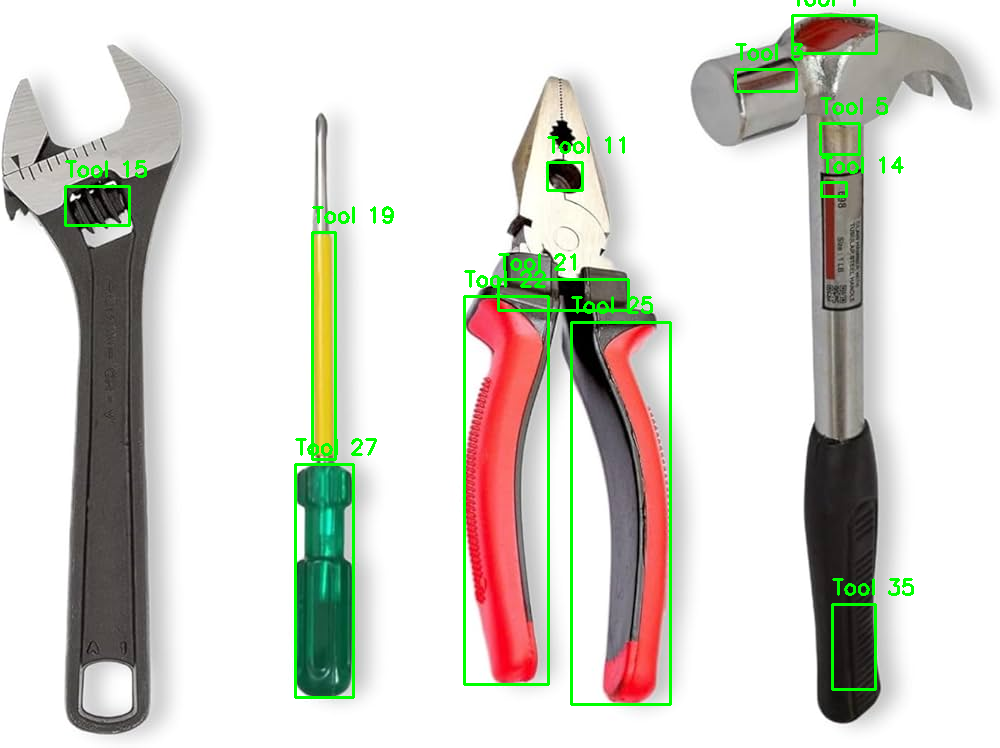

In [ ]:
result = img_3.copy()

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > 250:
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(result, f'Tool {i}', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

cv2_imshow(result)

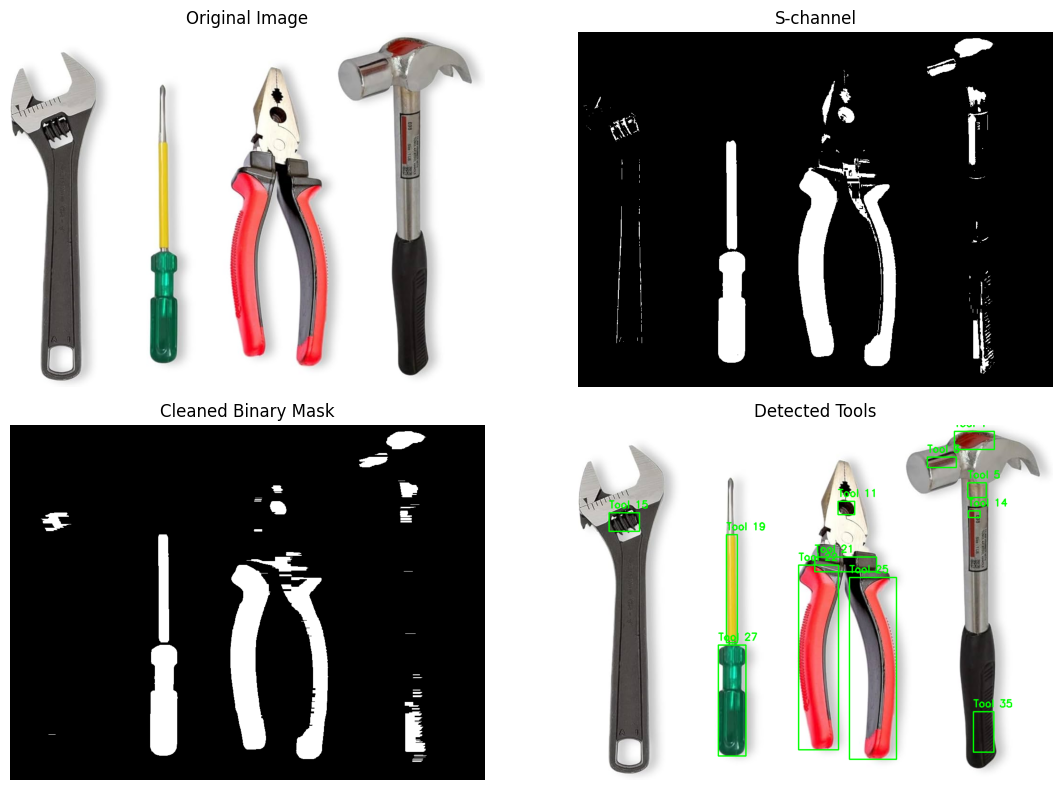

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img_3, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(b_mask, cmap='gray')
plt.title('S-channel')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(opening, cmap='gray')
plt.title('Cleaned Binary Mask')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Detected Tools')
plt.axis('off')

plt.tight_layout()
plt.show()